In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Tuple
import numpy as np

from deltafq.strategy.base import BaseStrategy


In [2]:
# 1. 读取基金数据，并重命名列名，以适应dfq回测等
data = pd.read_csv("160119.csv", index_col='净值日期')
data.index = pd.to_datetime(data.index)
data = data.rename(columns={'单位净值': 'close'})
data.index.name = 'date'

# 定义回测日期
start_date = '2021-01-01'
end_date = '2025-12-25'
data = data[start_date:end_date]

data


,close,累计净值,日增长率,申购状态,赎回状态,分红送配
date,,,,,,
2021-01-04,1.6907,1.7907,1.74%,开放申购,开放赎回,NaN
2021-01-05,1.7046,1.8046,0.82%,开放申购,开放赎回,NaN
2021-01-06,1.7018,1.8018,-0.16%,开放申购,开放赎回,NaN
2021-01-07,1.7042,1.8042,0.14%,开放申购,开放赎回,NaN
2021-01-08,1.7096,1.8096,0.32%,开放申购,开放赎回,NaN
...,...,...,...,...,...,...
2025-12-19,2.0168,2.1168,0.94%,开放申购,开放赎回,NaN
2025-12-22,2.0399,2.1399,1.15%,开放申购,开放赎回,NaN
2025-12-23,2.0401,2.1401,0.01%,开放申购,开放赎回,NaN


In [3]:
# 2. 智能定投策略：每周四定投，根据成本价和MA趋势动态调整金额
class SmartDCAStrategy(BaseStrategy):
    """
    智能定投策略：定期不定额
    
    策略逻辑：
    - 每周四定投（如周四非交易日，则选择最近交易日）
    - 基准金额：1000元
    - 金额范围：500-2000元
    - 金额调整：根据成本价和MA趋势
        * 下跌行情（价格<成本价 或 价格<MA）：多买（接近2000元）
        * 上涨行情（价格>成本价 且 价格>MA）：少买（接近500元）
    """
    
    def __init__(self, 
                 base_amount: float = 1000,
                 min_amount: float = 500,
                 max_amount: float = 2000,
                 ma_period: int = 60,
                 name: str = "SmartDCAStrategy"):
        """
        Args:
            base_amount: 基准定投金额，默认1000元
            min_amount: 最小定投金额，默认500元
            max_amount: 最大定投金额，默认2000元
            ma_period: 移动平均线周期，默认60日
            name: 策略名称
        """
        super().__init__(name=name)
        self.base_amount = base_amount
        self.min_amount = min_amount
        self.max_amount = max_amount
        self.ma_period = ma_period
    
    def generate_signals(self, data: pd.DataFrame) -> pd.Series:
        """
        生成每周四的定投信号
        
        核心逻辑：
        1. 每周四生成定投信号
        2. 如周四非交易日，选择最近交易日
        """
        signals = pd.Series(0, index=data.index, dtype=int)
        
        # 获取数据的时间范围
        start_date = data.index[0]
        end_date = data.index[-1]
        
        # 生成所有周四的日期
        thursdays = pd.date_range(start=start_date, end=end_date, freq='W-THU')
        
        # 对每个周四，找到最近的交易日
        for thursday in thursdays:
            # 使用 asof 找到最近的交易日（向前查找）
            nearest = data.index.asof(thursday)
            if nearest is not pd.NaT and nearest in data.index:
                # 如果找到的交易日还没有被标记，则标记
                if signals.loc[nearest] == 0:
                    signals.loc[nearest] = 1
            else:
                # 如果向前找不到，向后查找第一个交易日
                after = data.index[data.index > thursday]
                if len(after) > 0:
                    nearest = after[0]
                    if signals.loc[nearest] == 0:
                        signals.loc[nearest] = 1
        
        return signals
    
    def calculate_investment_amount(self, 
                                   current_price: float,
                                   cost_price: float,
                                   ma_price: float) -> float:
        """
        根据成本价和MA趋势计算定投金额（优化版：增强下跌补仓能力）
        
        Args:
            current_price: 当前价格
            cost_price: 平均成本价
            ma_price: MA价格
            
        Returns:
            定投金额（在min_amount和max_amount之间）
        """
        if cost_price == 0 or ma_price == 0:
            # 如果还没有成本价（首次买入）或MA未形成，使用基准金额
            return self.base_amount
        
        # 计算跌幅百分比（负数表示下跌，正数表示上涨）
        # 成本价跌幅：当前价相对成本价的跌幅
        cost_drawdown = (current_price - cost_price) / cost_price  # 负数表示低于成本价
        
        # MA跌幅：当前价相对MA的跌幅
        ma_drawdown = (current_price - ma_price) / ma_price  # 负数表示低于MA
        
        # 使用加权平均，成本价权重70%，MA权重30%（成本价更重要，更能反映个人持仓）
        combined_drawdown = cost_drawdown * 0.7 + ma_drawdown * 0.3
        
        # 将跌幅转换为调整系数，使用更激进的非线性函数
        # 使用分段函数：在关键阈值处使用最大值/最小值，中间区域使用平滑过渡
        
        # 阈值设定：更敏感，让小幅波动也能产生明显差异
        # 下跌5%以上就开始大幅增加，上涨5%以上就开始大幅减少
        if combined_drawdown <= -0.10:
            # 大幅下跌（≥10%）：使用最大调整系数2.0
            # 进一步根据跌幅深度增加（最多可以到2.0）
            extra_bonus = min(abs(combined_drawdown) - 0.10, 0.10) / 0.10 * 0.2  # 额外0-0.2
            adjustment_factor = min(2.0 + extra_bonus, 2.0)  # 最高2.0
        elif combined_drawdown >= 0.10:
            # 大幅上涨（≥10%）：使用最小调整系数0.5
            # 进一步根据涨幅深度减少（最少可以到0.5）
            extra_penalty = min(combined_drawdown - 0.10, 0.10) / 0.10 * 0.1  # 额外0-0.1
            adjustment_factor = max(0.5 - extra_penalty, 0.5)  # 最低0.5
        else:
            # 中间区域：使用更激进的映射函数
            # 将[-0.10, 0.10]映射到[2.0, 0.5]
            # 使用指数函数来放大中间区域的差异
            normalized = (combined_drawdown + 0.10) / 0.20  # 归一化到[0, 1]
            # 使用指数映射：当normalized接近0时（下跌），factor接近2.0
            # 当normalized接近1时（上涨），factor接近0.5
            # 使用更激进的指数函数：factor = 2.0 * (1 - normalized)^1.5
            adjustment_factor = 2.0 * ((1 - normalized) ** 1.5)
        
        # 进一步优化：基于成本价的额外调整（更激进的补仓逻辑）
        # 如果当前价格低于成本价，进一步增加定投金额
        if current_price < cost_price:
            # 跌幅越大，补仓越激进
            cost_drop_pct = (cost_price - current_price) / cost_price  # 跌幅百分比
            # 当跌幅5%时，额外增加5%；当跌幅20%时，额外增加20%（但最多到2.0）
            cost_bonus = 1.0 + min(cost_drop_pct * 1.5, 0.3)  # 最多额外30%
            adjustment_factor = min(adjustment_factor * cost_bonus, 2.0)
        
        # 如果当前价格远高于成本价，进一步减少定投金额
        if current_price > cost_price * 1.05:  # 当前价高于成本价5%以上
            # 涨幅越大，减仓越激进
            cost_rise_pct = (current_price - cost_price) / cost_price  # 涨幅百分比
            # 当涨幅10%时，额外减少10%；当涨幅30%时，额外减少30%（但最少到0.5）
            cost_penalty = 1.0 - min(cost_rise_pct * 0.8, 0.3)  # 最多额外减少30%
            adjustment_factor = max(adjustment_factor * cost_penalty, 0.5)
        
        # 限制调整系数范围：0.5到2.0
        adjustment_factor = np.clip(adjustment_factor, 0.5, 2.0)
        
        # 计算定投金额
        investment_amount = self.base_amount * adjustment_factor
        
        # 限制在最小和最大金额之间
        investment_amount = np.clip(investment_amount, self.min_amount, self.max_amount)
        
        return investment_amount

# 使用策略
strategy = SmartDCAStrategy(
    base_amount=1000,
    min_amount=500,
    max_amount=2000,
    ma_period=20,
    name="SmartDCAStrategy"
)
result = strategy.run(data)
signals = result["signals"]

print(f"策略名称: {result['strategy_name']}")
print(f"基准金额: {strategy.base_amount}元")
print(f"金额范围: {strategy.min_amount}-{strategy.max_amount}元")
print(f"MA周期: {strategy.ma_period}日")
print(f"定投信号数: {(signals == 1).sum()}")
print(f"持有信号数: {(signals == 0).sum()}")


[22:41:32] SmartDCAStrategy     >>> INFO     >>> Initializing strategy: SmartDCAStrategy
[22:41:32] SmartDCAStrategy     >>> INFO     >>> Running strategy: SmartDCAStrategy
策略名称: SmartDCAStrategy
基准金额: 1000元
金额范围: 500-2000元
MA周期: 20日
定投信号数: 257
持有信号数: 954


In [4]:
# 查看信号
signals

# 3. 分析定投金额分布（在回测后查看）
# 这个cell需要先运行回测才能看到结果


date
2021-01-04    0
2021-01-05    0
2021-01-06    0
2021-01-07    1
2021-01-08    0
             ..
2025-12-19    0
2025-12-22    0
2025-12-23    0
2025-12-24    0
2025-12-25    1
Length: 1211, dtype: int64

In [5]:
# 4. 回测智能定投策略：动态计算每次定投金额
from datetime import datetime

def backtest_smart_dca(data: pd.DataFrame, 
                       signals: pd.Series,
                       strategy: SmartDCAStrategy,
                       commission: float = 0.001) -> Tuple[pd.DataFrame, dict]:
    """
    智能定投策略回测
    
    Args:
        data: 包含close列的数据
        signals: 买入信号序列（1=定投，0=持有）
        strategy: 策略对象（包含计算金额的方法）
        commission: 手续费率
    
    Returns:
        values_df: 每日资产明细（包含investment_amount列）
        summary: 回测摘要
    """
    shares = 0
    total_invested = 0
    records = []
    
    # 计算MA
    ma = data['close'].rolling(window=strategy.ma_period, min_periods=1).mean()
    
    for date, row in data.iterrows():
        price = row['close']
        signal = signals.loc[date] if date in signals.index else 0
        ma_price = ma.loc[date] if date in ma.index else price
        
        # 计算当前成本价（累计投入/累计份额）
        cost_price = total_invested / shares if shares > 0 else 0
        
        # 定投信号：根据成本价和MA动态计算定投金额
        investment_amount = 0
        if signal == 1:
            # 计算动态定投金额
            # 如果还没有成本价，使用当前价作为成本价进行计算
            effective_cost_price = cost_price if cost_price > 0 else price
            investment_amount = strategy.calculate_investment_amount(
                current_price=price,
                cost_price=effective_cost_price,
                ma_price=ma_price
            )
            
            # 投入金额，扣除手续费后用于买入
            net_amount = investment_amount * (1 - commission)
            shares_bought = net_amount / price
            shares += shares_bought
            total_invested += investment_amount
        
        # 计算资产
        position_value = shares * price
        total_value = position_value
        current_cost_price = total_invested / shares if shares > 0 else 0
        
        records.append({
            'date': date,
            'price': price,
            'ma': ma_price,
            'signal': signal,
            'investment_amount': investment_amount,
            'cost_price': current_cost_price,
            'shares': shares,
            'position_value': position_value,
            'total_value': total_value,
            'total_invested': total_invested
        })
    
    values_df = pd.DataFrame(records).set_index('date')
    
    # 计算摘要
    final_value = values_df['total_value'].iloc[-1]
    total_return = (final_value / total_invested - 1) * 100 if total_invested > 0 else 0
    buy_count = (signals == 1).sum()
    
    # 计算金额统计
    investment_amounts = values_df[values_df['investment_amount'] > 0]['investment_amount']
    avg_investment = investment_amounts.mean() if len(investment_amounts) > 0 else 0
    min_investment = investment_amounts.min() if len(investment_amounts) > 0 else 0
    max_investment = investment_amounts.max() if len(investment_amounts) > 0 else 0
    
    # 计算年化收益率
    start_date = values_df.index[0]
    end_date = values_df.index[-1]
    years = (end_date - start_date).days / 365.25
    annual_return = ((final_value / total_invested) ** (1 / years) - 1) * 100 if total_invested > 0 and years > 0 else 0
    
    summary = {
        '累计投入': f'{total_invested:,.2f}',
        '最终资产': f'{final_value:,.2f}',
        '累计收益': f'{final_value - total_invested:,.2f}',
        '累计收益率': f'{total_return:.2f}%',
        '年化收益率': f'{annual_return:.2f}%',
        '投资年限': f'{years:.2f}年',
        '定投次数': buy_count,
        '平均定投金额': f'{avg_investment:,.2f}',
        '最小定投金额': f'{min_investment:,.2f}',
        '最大定投金额': f'{max_investment:,.2f}',
        '持有份额': f'{shares:,.4f}',
        '最终净值': f'{values_df["price"].iloc[-1]:.4f}',
        '最终成本价': f'{values_df["cost_price"].iloc[-1]:.4f}',
        '起始日期': start_date.strftime('%Y-%m-%d'),
        '结束日期': end_date.strftime('%Y-%m-%d')
    }
    
    return values_df, summary

def print_summary(summary: dict, title: str = "回测摘要"):
    """格式化打印回测摘要"""
    print("=" * 50)
    print(f"  {title}")
    print("=" * 50)
    for key, value in summary.items():
        print(f"  {key:12s}: {value}")
    print("=" * 50)

# 运行回测
values_df, summary = backtest_smart_dca(data, signals, strategy, commission=0)

# 格式化打印摘要
print_summary(summary)

# 查看最近10天资产
print("\n最近10天资产:")
print(values_df[['price', 'ma', 'cost_price', 'signal', 'investment_amount', 
                 'shares', 'total_value', 'total_invested']].tail(10))


  回测摘要
  累计投入        : 236,668.80
  最终资产        : 312,158.30
  累计收益        : 75,489.50
  累计收益率       : 31.90%
  年化收益率       : 5.73%
  投资年限        : 4.97年
  定投次数        : 257
  平均定投金额      : 920.89
  最小定投金额      : 500.00
  最大定投金额      : 2,000.00
  持有份额        : 149,939.1411
  最终净值        : 2.0819
  最终成本价       : 1.5784
  起始日期        : 2021-01-04
  结束日期        : 2025-12-25

最近10天资产:
             price        ma  cost_price  signal  investment_amount  \
date                                                                  
2025-12-12  2.0172  1.983335    1.576921       0                0.0   
2025-12-15  2.0013  1.981885    1.576921       0                0.0   
2025-12-16  1.9708  1.980030    1.576921       0                0.0   
2025-12-17  2.0077  1.980380    1.576921       0                0.0   
2025-12-18  1.9981  1.981055    1.577625       1              500.0   
2025-12-19  2.0168  1.985920    1.577625       0                0.0   
2025-12-22  2.0399  1.991255    1.577625       0


定投金额分布分析:
总定投次数: 257
平均定投金额: 920.89元
中位数定投金额: 671.34元
最小定投金额: 500.00元
最大定投金额: 2000.00元
标准差: 513.25元
变异系数 (CV): 55.73%

金额分布区间:
  500-800元: 143次 (55.6%)
  800-1000元: 28次 (10.9%)
  1000-1200元: 14次 (5.4%)
  1200-1500元: 27次 (10.5%)
  1500-2000元: 45次 (17.5%)


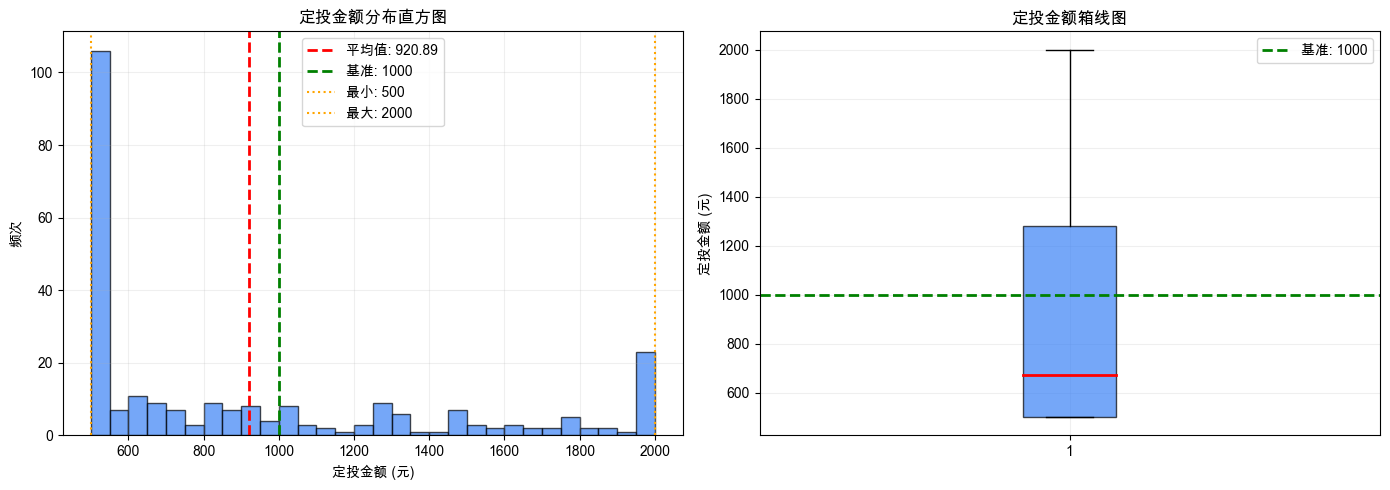

In [11]:
# 5.5 分析定投金额分布情况
investment_amounts_series = values_df[values_df['investment_amount'] > 0]['investment_amount']

if len(investment_amounts_series) > 0:
    print("\n定投金额分布分析:")
    print("=" * 60)
    print(f"总定投次数: {len(investment_amounts_series)}")
    print(f"平均定投金额: {investment_amounts_series.mean():.2f}元")
    print(f"中位数定投金额: {investment_amounts_series.median():.2f}元")
    print(f"最小定投金额: {investment_amounts_series.min():.2f}元")
    print(f"最大定投金额: {investment_amounts_series.max():.2f}元")
    print(f"标准差: {investment_amounts_series.std():.2f}元")
    print(f"变异系数 (CV): {(investment_amounts_series.std() / investment_amounts_series.mean() * 100):.2f}%")
    print("\n金额分布区间:")
    count_500_800 = ((investment_amounts_series >= 500) & (investment_amounts_series < 800)).sum()
    count_800_1000 = ((investment_amounts_series >= 800) & (investment_amounts_series < 1000)).sum()
    count_1000_1200 = ((investment_amounts_series >= 1000) & (investment_amounts_series < 1200)).sum()
    count_1200_1500 = ((investment_amounts_series >= 1200) & (investment_amounts_series < 1500)).sum()
    count_1500_2000 = ((investment_amounts_series >= 1500) & (investment_amounts_series <= 2000)).sum()
    total_count = len(investment_amounts_series)
    
    print(f"  500-800元: {count_500_800}次 ({count_500_800 / total_count * 100:.1f}%)")
    print(f"  800-1000元: {count_800_1000}次 ({count_800_1000 / total_count * 100:.1f}%)")
    print(f"  1000-1200元: {count_1000_1200}次 ({count_1000_1200 / total_count * 100:.1f}%)")
    print(f"  1200-1500元: {count_1200_1500}次 ({count_1200_1500 / total_count * 100:.1f}%)")
    print(f"  1500-2000元: {count_1500_2000}次 ({count_1500_2000 / total_count * 100:.1f}%)")
    print("=" * 60)
    
    # 绘制金额分布直方图
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 直方图
    ax1.hist(investment_amounts_series, bins=30, color="#3b82f6", alpha=0.7, edgecolor='black')
    ax1.axvline(investment_amounts_series.mean(), color='red', linestyle='--', linewidth=2, label=f'平均值: {investment_amounts_series.mean():.2f}')
    ax1.axvline(strategy.base_amount, color='green', linestyle='--', linewidth=2, label=f'基准: {strategy.base_amount}')
    ax1.axvline(strategy.min_amount, color='orange', linestyle=':', linewidth=1.5, label=f'最小: {strategy.min_amount}')
    ax1.axvline(strategy.max_amount, color='orange', linestyle=':', linewidth=1.5, label=f'最大: {strategy.max_amount}')
    ax1.set_xlabel('定投金额 (元)')
    ax1.set_ylabel('频次')
    ax1.set_title('定投金额分布直方图')
    ax1.legend()
    ax1.grid(True, alpha=0.2)
    
    # 箱线图
    ax2.boxplot(investment_amounts_series, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#3b82f6", alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.axhline(strategy.base_amount, color='green', linestyle='--', linewidth=2, label=f'基准: {strategy.base_amount}')
    ax2.set_ylabel('定投金额 (元)')
    ax2.set_title('定投金额箱线图')
    ax2.legend()
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("暂无定投数据")


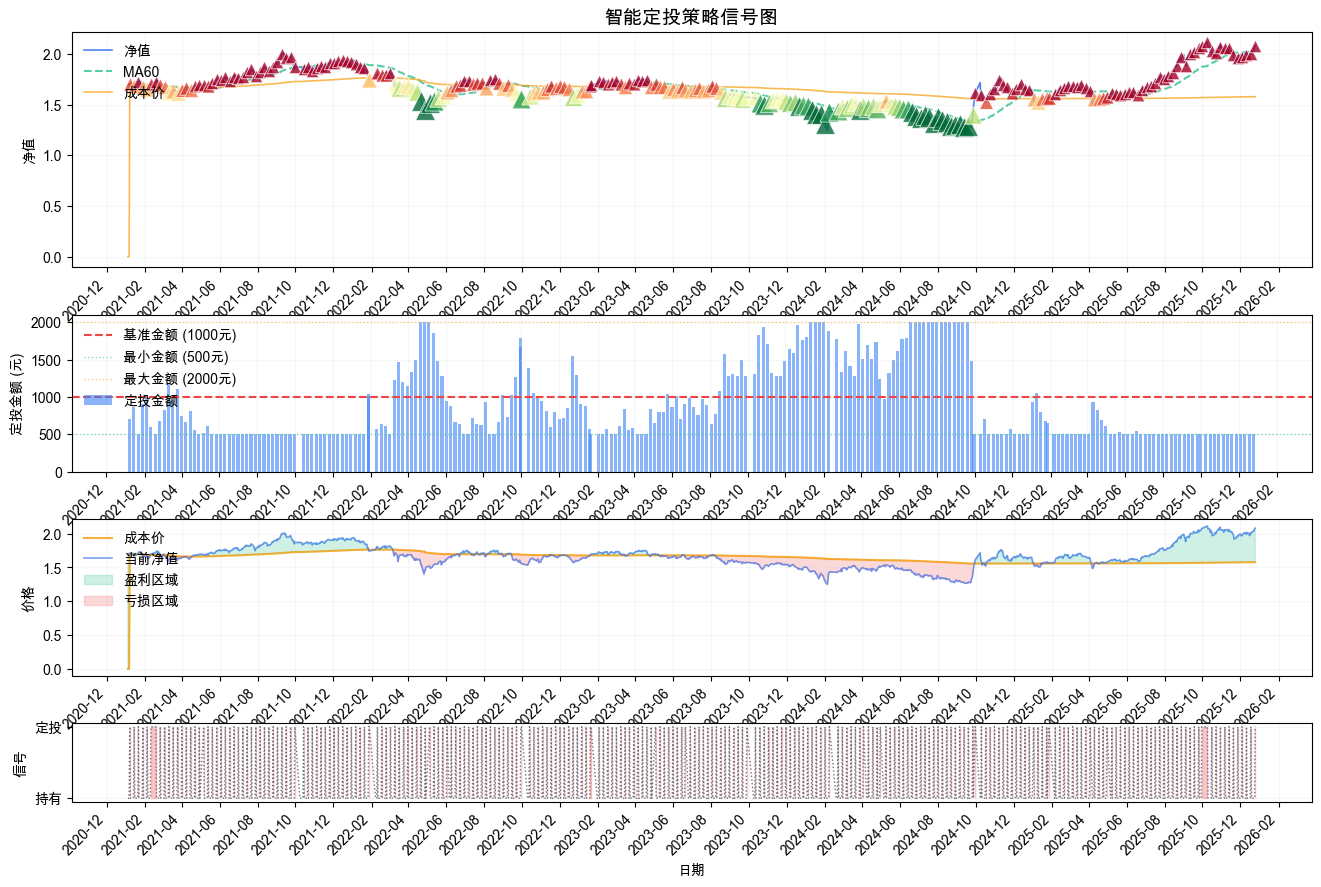

In [7]:
# 5. 可视化智能定投策略信号和定投金额
def plot_smart_dca_signals(data: pd.DataFrame, 
                           values_df: pd.DataFrame,
                           signals: pd.Series,
                           ma_period: int = 60,
                           title: str = "智能定投策略信号图") -> None:
    """可视化基金价格、MA、成本价、买入信号和定投金额"""
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(4, 1, height_ratios=[3, 2, 2, 1], hspace=0.3)
    
    ax_price = fig.add_subplot(gs[0])
    ax_amount = fig.add_subplot(gs[1])
    ax_cost = fig.add_subplot(gs[2])
    ax_signal = fig.add_subplot(gs[3])
    
    # 计算MA
    ma = data['close'].rolling(window=ma_period, min_periods=1).mean()
    
    # 价格图
    ax_price.plot(data.index, data['close'], color="#2563eb", linewidth=1.2, label="净值", alpha=0.8)
    ax_price.plot(data.index, ma, color="#10b981", linewidth=1.5, 
                  linestyle="--", label=f"MA{ma_period}", alpha=0.7)
    ax_price.plot(values_df.index, values_df['cost_price'], color="#f59e0b", 
                  linewidth=1.2, label="成本价", alpha=0.7)
    
    buy_mask = signals == 1
    buy_dates = data.index[buy_mask]
    buy_prices = data['close'][buy_mask]
    
    # 根据定投金额大小调整标记大小和颜色
    buy_amounts = values_df.loc[buy_dates, 'investment_amount'] if len(buy_dates) > 0 else pd.Series()
    
    if len(buy_amounts) > 0:
        # 将金额映射到颜色和大小
        min_amount = buy_amounts.min()
        max_amount = buy_amounts.max()
        if max_amount > min_amount:
            colors = plt.cm.RdYlGn((buy_amounts - min_amount) / (max_amount - min_amount))
            sizes = 80 + (buy_amounts - min_amount) / (max_amount - min_amount) * 120
        else:
            colors = ['#ef4444'] * len(buy_amounts)
            sizes = [140] * len(buy_amounts)
        
        for date, price, color, size, amount in zip(buy_dates, buy_prices, colors, sizes, buy_amounts):
            ax_price.scatter(date, price, c=[color], s=size, marker="^", 
                           edgecolors="white", linewidths=0.6, zorder=3, alpha=0.8)
    
    ax_price.set_title(title, fontsize=14, fontweight='bold')
    ax_price.set_ylabel("净值")
    ax_price.grid(True, alpha=0.2, color="#d1d5db")
    ax_price.legend(frameon=False, loc="upper left")
    
    # 定投金额图
    investment_dates = values_df[values_df['investment_amount'] > 0].index
    investment_amounts = values_df.loc[investment_dates, 'investment_amount']
    
    if len(investment_dates) > 0:
        ax_amount.bar(investment_dates, investment_amounts, 
                     color="#3b82f6", alpha=0.6, width=5, label="定投金额")
        ax_amount.axhline(y=strategy.base_amount, color="#ef4444", linestyle="--", 
                         linewidth=1.5, label=f"基准金额 ({strategy.base_amount}元)")
        ax_amount.axhline(y=strategy.min_amount, color="#10b981", linestyle=":", 
                         linewidth=1.0, alpha=0.5, label=f"最小金额 ({strategy.min_amount}元)")
        ax_amount.axhline(y=strategy.max_amount, color="#f59e0b", linestyle=":", 
                         linewidth=1.0, alpha=0.5, label=f"最大金额 ({strategy.max_amount}元)")
    
    ax_amount.set_ylabel("定投金额 (元)")
    ax_amount.grid(True, alpha=0.2, color="#d1d5db")
    ax_amount.legend(frameon=False, loc="upper left")
    
    # 成本价对比图
    ax_cost.plot(values_df.index, values_df['cost_price'], color="#f59e0b", 
                linewidth=1.5, label="成本价", alpha=0.8)
    ax_cost.plot(values_df.index, values_df['price'], color="#2563eb", 
                linewidth=1.2, label="当前净值", alpha=0.6)
    
    # 填充区域：成本价低于净值的区域（盈利）和高于净值的区域（亏损）
    ax_cost.fill_between(values_df.index, values_df['cost_price'], values_df['price'],
                        where=(values_df['cost_price'] <= values_df['price']),
                        color="#10b981", alpha=0.2, label="盈利区域")
    ax_cost.fill_between(values_df.index, values_df['cost_price'], values_df['price'],
                        where=(values_df['cost_price'] > values_df['price']),
                        color="#ef4444", alpha=0.2, label="亏损区域")
    
    ax_cost.set_ylabel("价格")
    ax_cost.grid(True, alpha=0.2, color="#d1d5db")
    ax_cost.legend(frameon=False, loc="upper left")
    
    # 信号图
    ax_signal.plot(signals.index, signals.values, color="#6b7280", linewidth=1.0, linestyle=":")
    ax_signal.fill_between(signals.index, 0, signals.values, 
                          where=(signals == 1), color="#ef4444", alpha=0.3)
    ax_signal.set_ylabel("信号")
    ax_signal.set_xlabel("日期")
    ax_signal.set_yticks([0, 1])
    ax_signal.set_yticklabels(["持有", "定投"])
    ax_signal.grid(True, alpha=0.2, color="#d1d5db")
    
    # 日期格式
    for ax in (ax_price, ax_amount, ax_cost, ax_signal):
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

plot_smart_dca_signals(data, values_df, signals, ma_period=60)


[22:41:37] PerformanceChart     >>> INFO     >>> Initializing performance chart


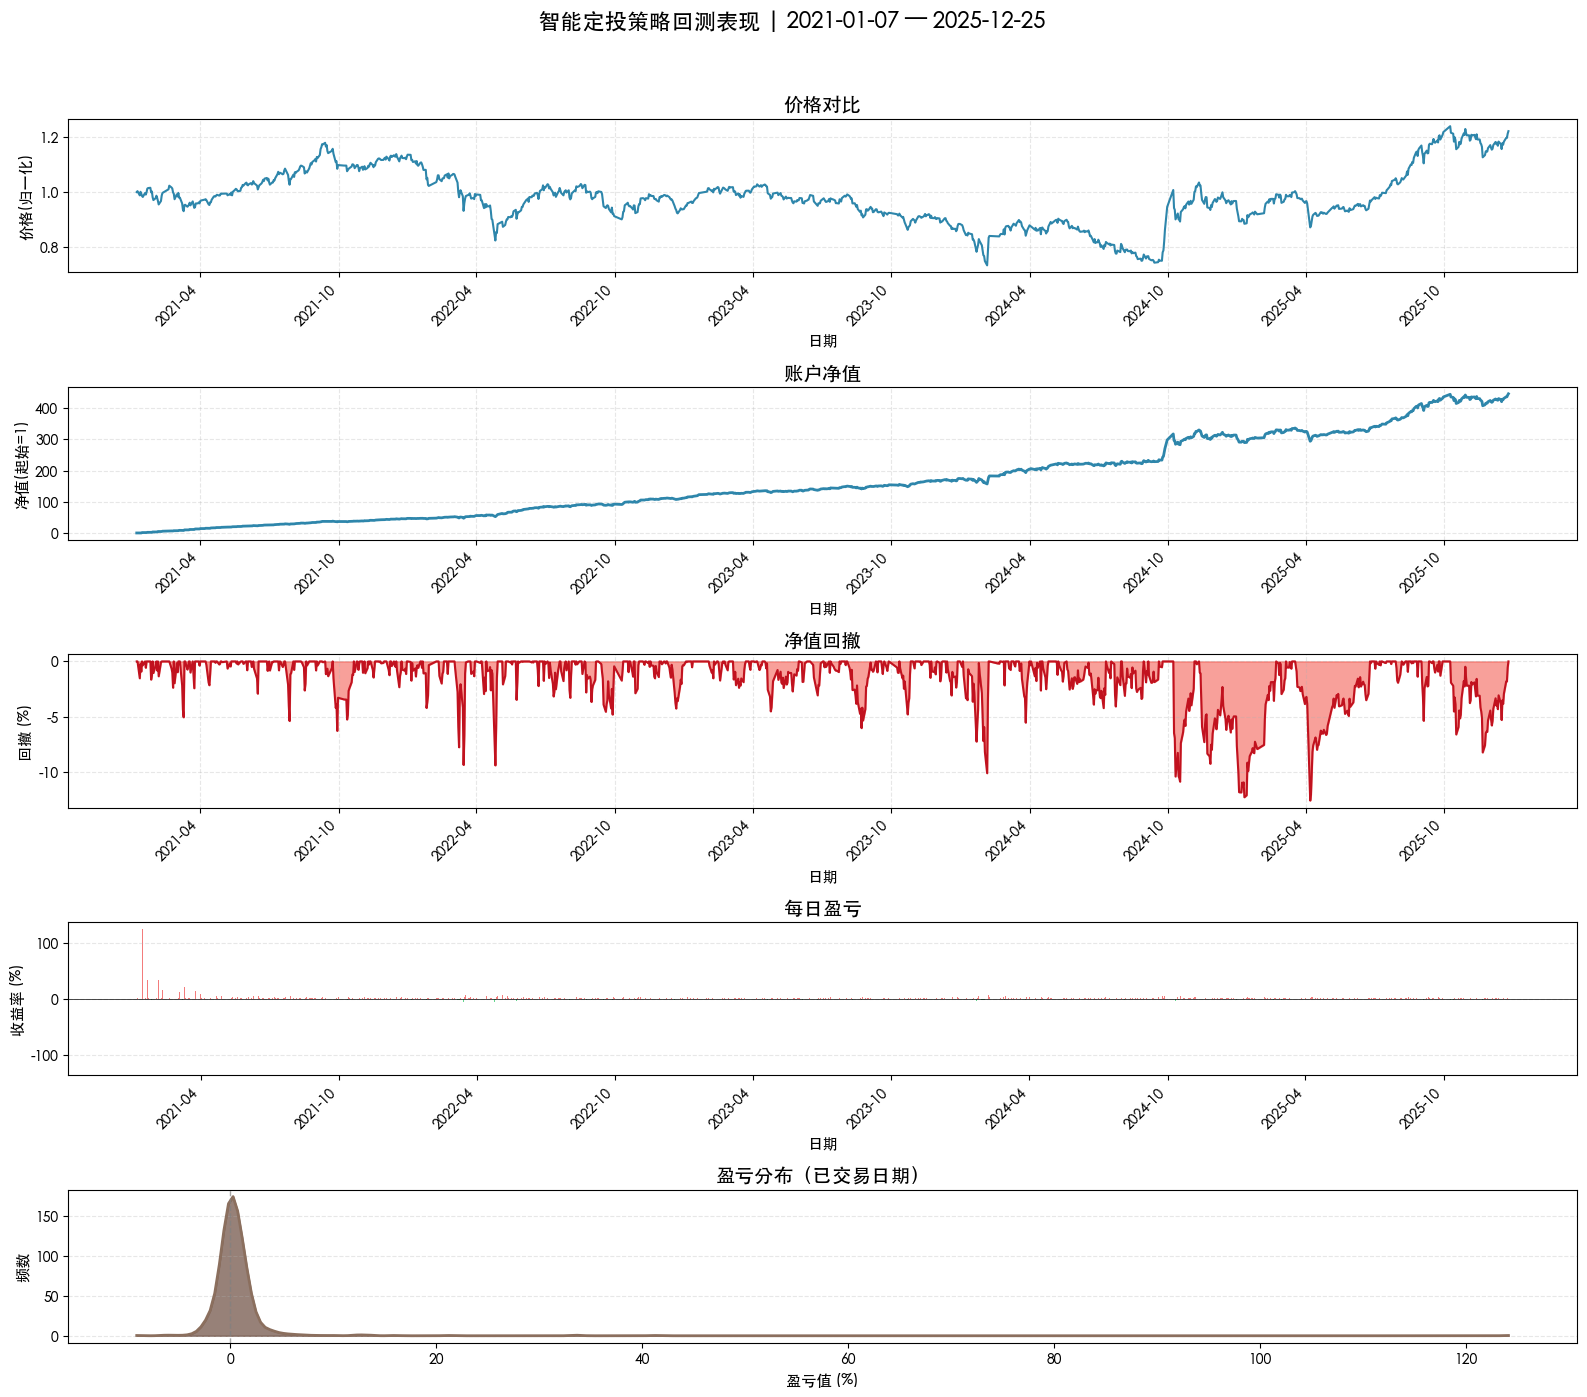

In [8]:
# 6. 可视化回测结果
from deltafq.charts import PerformanceChart

def plot_backtest_performance(values_df: pd.DataFrame, 
                              benchmark_close: pd.Series = None,
                              title: str = "智能定投策略回测表现",
                              use_plotly: bool = False):
    """使用PerformanceChart可视化回测结果"""
    # 确保 values_df 格式正确
    values_df = values_df.copy()
    
    # 从第一次有资产开始（避免初始为0导致的计算问题）
    first_valid_idx = values_df[values_df['total_value'] > 0].index
    if len(first_valid_idx) > 0:
        values_df = values_df.loc[first_valid_idx[0]:]
    
    # 清理无效值
    values_df['total_value'] = values_df['total_value'].replace([float('inf'), -float('inf')], 0)
    values_df['total_value'] = values_df['total_value'].fillna(0)
    values_df['price'] = values_df['price'].fillna(method='ffill').fillna(method='bfill')
    
    # 确保 total_value 至少有一个非零值
    if (values_df['total_value'] == 0).all():
        values_df.loc[values_df.index[0], 'total_value'] = 1.0
    
    # 对齐 benchmark_close 索引
    if benchmark_close is not None:
        benchmark_close = benchmark_close.reindex(values_df.index, method='ffill').fillna(method='bfill')
        # 清理 benchmark 的无效值
        benchmark_close = benchmark_close.replace([float('inf'), -float('inf')], 0)
        benchmark_close = benchmark_close.fillna(method='ffill').fillna(method='bfill')
    
    performance_chart = PerformanceChart()
    performance_chart.plot_backtest_charts(
        values_df=values_df,
        benchmark_close=benchmark_close,
        title=title,
        use_plotly=use_plotly
    )

plot_backtest_performance(values_df=values_df)


In [9]:
# 7. 对比分析：智能定投 vs 固定金额定投
# 使用固定金额定投策略作为基准对比

# 固定金额定投策略类（参考20.2）
class DCAStrategy(BaseStrategy):
    """每周四定投策略（固定金额）"""
    
    def generate_signals(self, data: pd.DataFrame) -> pd.Series:
        signals = pd.Series(0, index=data.index, dtype=int)
        start_date = data.index[0]
        end_date = data.index[-1]
        thursdays = pd.date_range(start=start_date, end=end_date, freq='W-THU')
        
        for thursday in thursdays:
            nearest = data.index.asof(thursday)
            if nearest is not pd.NaT and nearest in data.index:
                if signals.loc[nearest] == 0:
                    signals.loc[nearest] = 1
            else:
                after = data.index[data.index > thursday]
                if len(after) > 0:
                    nearest = after[0]
                    if signals.loc[nearest] == 0:
                        signals.loc[nearest] = 1
        return signals

# 固定金额定投（基准1000元）
dca_strategy = DCAStrategy(name="DCAStrategy_Fixed1000")
dca_result = dca_strategy.run(data)
dca_signals = dca_result["signals"]

# 回测固定金额定投
def backtest_fixed_dca(data: pd.DataFrame, signals: pd.Series, 
                       investment_amount: float = 1000, 
                       commission: float = 0.001) -> Tuple[pd.DataFrame, dict]:
    """固定金额定投回测（参考20.2）"""
    shares = 0
    total_invested = 0
    records = []
    
    for date, row in data.iterrows():
        price = row['close']
        signal = signals.loc[date] if date in signals.index else 0
        
        if signal == 1:
            net_amount = investment_amount * (1 - commission)
            shares_bought = net_amount / price
            shares += shares_bought
            total_invested += investment_amount
        
        position_value = shares * price
        total_value = position_value
        
        records.append({
            'date': date,
            'price': price,
            'signal': signal,
            'shares': shares,
            'total_value': total_value,
            'total_invested': total_invested
        })
    
    values_df = pd.DataFrame(records).set_index('date')
    
    final_value = values_df['total_value'].iloc[-1]
    total_return = (final_value / total_invested - 1) * 100 if total_invested > 0 else 0
    buy_count = (signals == 1).sum()
    
    start_date = values_df.index[0]
    end_date = values_df.index[-1]
    years = (end_date - start_date).days / 365.25
    annual_return = ((final_value / total_invested) ** (1 / years) - 1) * 100 if total_invested > 0 and years > 0 else 0
    
    summary = {
        '累计投入': total_invested,
        '最终资产': final_value,
        '累计收益率': total_return,
        '年化收益率': annual_return,
        '定投次数': buy_count,
        '每次定投金额': investment_amount
    }
    
    return values_df, summary

# 运行固定金额定投回测
dca_values_df, dca_summary = backtest_fixed_dca(data, dca_signals, investment_amount=1000, commission=0)

# 获取智能定投的数值型摘要（用于对比）
smart_summary_num = {
    '累计投入': float(summary['累计投入'].replace(',', '')),
    '最终资产': float(summary['最终资产'].replace(',', '')),
    '累计收益率': float(summary['累计收益率'].replace('%', '')),
    '年化收益率': float(summary['年化收益率'].replace('%', '')),
    '定投次数': int(summary['定投次数']),
    '平均定投金额': float(summary['平均定投金额'].replace(',', ''))
}

# 对比结果
comparison = pd.DataFrame({
    '策略': ['固定金额定投', '智能定投', '差值'],
    '累计投入': [
        f"{dca_summary['累计投入']:,.2f}",
        f"{smart_summary_num['累计投入']:,.2f}",
        f"{smart_summary_num['累计投入'] - dca_summary['累计投入']:,.2f}"
    ],
    '最终资产': [
        f"{dca_summary['最终资产']:,.2f}",
        f"{smart_summary_num['最终资产']:,.2f}",
        f"{smart_summary_num['最终资产'] - dca_summary['最终资产']:,.2f}"
    ],
    '累计收益率': [
        f"{dca_summary['累计收益率']:.2f}%",
        f"{smart_summary_num['累计收益率']:.2f}%",
        f"{smart_summary_num['累计收益率'] - dca_summary['累计收益率']:.2f}%"
    ],
    '年化收益率': [
        f"{dca_summary['年化收益率']:.2f}%",
        f"{smart_summary_num['年化收益率']:.2f}%",
        f"{smart_summary_num['年化收益率'] - dca_summary['年化收益率']:.2f}%"
    ],
    '定投次数': [
        dca_summary['定投次数'],
        smart_summary_num['定投次数'],
        smart_summary_num['定投次数'] - dca_summary['定投次数']
    ],
    '平均定投金额': [
        f"{dca_summary['每次定投金额']:,.2f}",
        f"{smart_summary_num['平均定投金额']:,.2f}",
        f"{smart_summary_num['平均定投金额'] - dca_summary['每次定投金额']:,.2f}"
    ]
})

print("\n策略对比分析:")
print("=" * 100)
print(comparison.to_string(index=False))
print("=" * 100)

# 计算超额收益
excess_return = smart_summary_num['累计收益率'] - dca_summary['累计收益率']
excess_asset = smart_summary_num['最终资产'] - dca_summary['最终资产']
print(f"\n智能定投相对固定定投：")
print(f"  超额收益率: {excess_return:.2f}%")
print(f"  超额收益金额: {excess_asset:,.2f}元")
if smart_summary_num['累计投入'] != dca_summary['累计投入']:
    print(f"  投入差异: {smart_summary_num['累计投入'] - dca_summary['累计投入']:,.2f}元")


[22:41:42] DCAStrategy_Fixed1000 >>> INFO     >>> Initializing strategy: DCAStrategy_Fixed1000
[22:41:42] DCAStrategy_Fixed1000 >>> INFO     >>> Running strategy: DCAStrategy_Fixed1000

策略对比分析:
    策略       累计投入       最终资产  累计收益率 年化收益率  定投次数   平均定投金额
固定金额定投 257,000.00 323,926.26 26.04% 4.76%   257 1,000.00
  智能定投 236,668.80 312,158.30 31.90% 5.73%   257   920.89
    差值 -20,331.20 -11,767.96  5.86% 0.97%     0   -79.11

智能定投相对固定定投：
  超额收益率: 5.86%
  超额收益金额: -11,767.96元
  投入差异: -20,331.20元


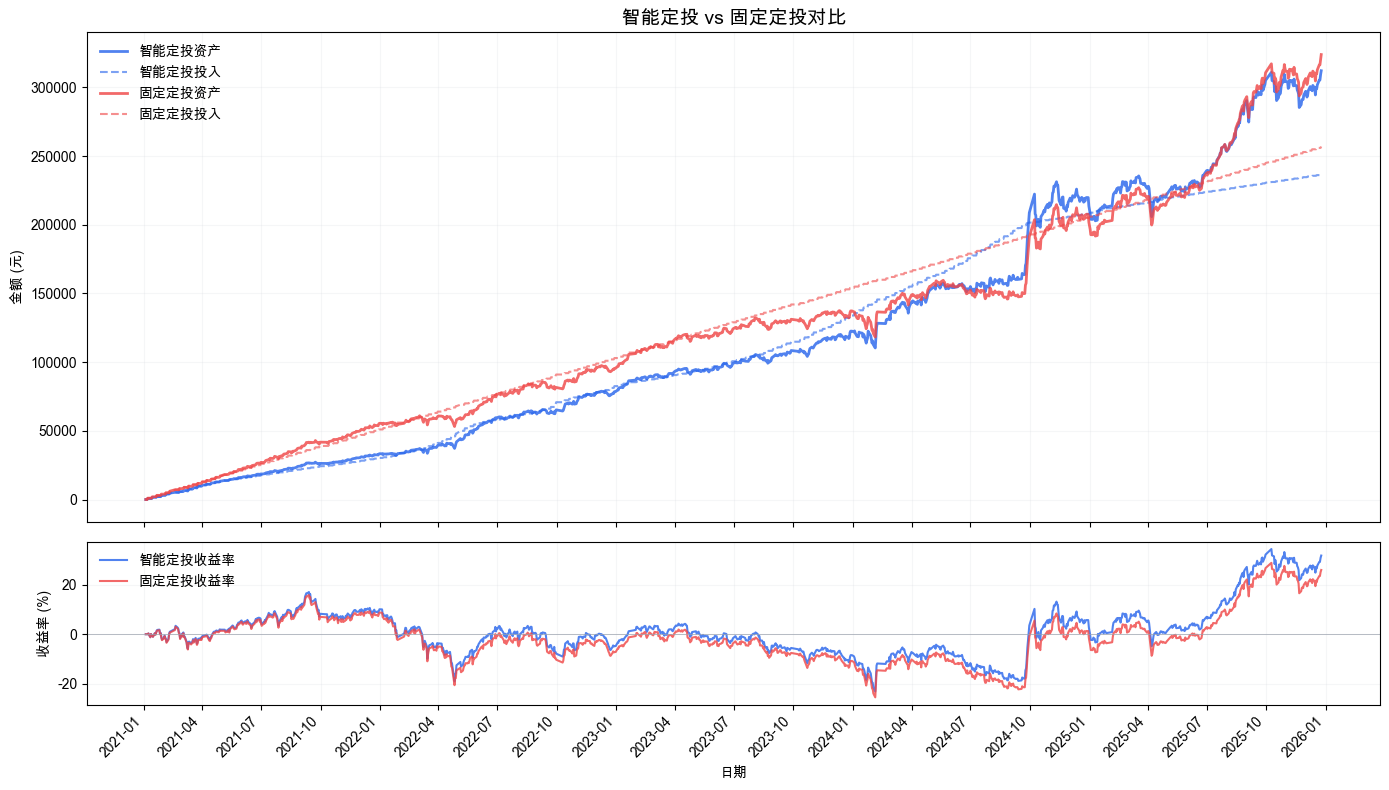

In [10]:
# 8. 可视化策略对比：资产曲线对比
def plot_strategy_comparison(smart_values_df: pd.DataFrame,
                             fixed_values_df: pd.DataFrame,
                             title: str = "智能定投 vs 固定定投对比"):
    """对比两种策略的资产曲线"""
    # 设置中文字体
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})
    
    # 资产曲线对比
    ax1.plot(smart_values_df.index, smart_values_df['total_value'], 
            color="#2563eb", linewidth=2.0, label="智能定投资产", alpha=0.8)
    ax1.plot(smart_values_df.index, smart_values_df['total_invested'], 
            color="#2563eb", linewidth=1.5, linestyle="--", label="智能定投投入", alpha=0.6)
    
    ax1.plot(fixed_values_df.index, fixed_values_df['total_value'], 
            color="#ef4444", linewidth=2.0, label="固定定投资产", alpha=0.8)
    ax1.plot(fixed_values_df.index, fixed_values_df['total_invested'], 
            color="#ef4444", linewidth=1.5, linestyle="--", label="固定定投投入", alpha=0.6)
    
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.set_ylabel("金额 (元)")
    ax1.grid(True, alpha=0.2, color="#d1d5db")
    ax1.legend(frameon=False, loc="upper left")
    
    # 收益率对比
    smart_return = ((smart_values_df['total_value'] - smart_values_df['total_invested']) 
                   / smart_values_df['total_invested'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
    fixed_return = ((fixed_values_df['total_value'] - fixed_values_df['total_invested']) 
                   / fixed_values_df['total_invested'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)
    
    ax2.plot(smart_values_df.index, smart_return, 
            color="#2563eb", linewidth=1.5, label="智能定投收益率", alpha=0.8)
    ax2.plot(fixed_values_df.index, fixed_return, 
            color="#ef4444", linewidth=1.5, label="固定定投收益率", alpha=0.8)
    ax2.axhline(y=0, color="#9ca3af", linestyle="-", linewidth=0.5)
    
    ax2.set_ylabel("收益率 (%)")
    ax2.set_xlabel("日期")
    ax2.grid(True, alpha=0.2, color="#d1d5db")
    ax2.legend(frameon=False, loc="upper left")
    
    # 日期格式
    for ax in (ax1, ax2):
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

plot_strategy_comparison(values_df, dca_values_df)
